## Data Preprocessing

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [16]:
df=pd.read_csv(r"usa_visadataset.csv")
df.shape

(25480, 12)

### Data cleaning

#### Handling missing values.

In [17]:
cols_with_missing_val=[col for col in df.columns if df[col].isnull().mean() > 0]
cols_with_missing_val

[]

There is no missing values in this data set.

#### Handling Duplicates

In [18]:
duplicates_count = int(df.duplicated().sum())
print(duplicates_count)

0


There is no duplicate value in the data set

#### Removing case_id feom the dataset

In [19]:
df.drop('case_id',axis=1,inplace=True)

In [20]:
df.head(2)

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified


###  Feature Extraction

In [21]:
from datetime import date

toadys_date=date.today()

current_year=toadys_date.year

print("Current year:",current_year)

Current year: 2024


#### Extracting the company age from the year of establishment.

In [22]:
df['Age_of_the_Company']=current_year-df['yr_of_estab']


In [23]:
df.drop('yr_of_estab', inplace=True, axis=1)

In [24]:
df.head(5)

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,Age_of_the_Company
0,Asia,High School,N,N,14513,West,592.2029,Hour,Y,Denied,17
1,Asia,Master's,Y,N,2412,Northeast,83425.6500,Year,Y,Certified,22
2,Asia,Bachelor's,N,Y,44444,West,122996.8600,Year,Y,Denied,16
3,Asia,Bachelor's,N,N,98,West,83434.0300,Year,Y,Denied,127
4,Africa,Master's,Y,N,1082,South,149907.3900,Year,Y,Certified,19


### Types of Features

Numeric Feature

In [25]:
Numeric_features=[column for column in df.columns if df[column].dtype!='O']
print(f"There is {len(Numeric_features)} numeric  features and they are:",Numeric_features)

There is 3 numeric  features and they are: ['no_of_employees', 'prevailing_wage', 'Age_of_the_Company']


Categorical Feature

In [26]:
Categorical_features=[column for column in df.columns if df[column].dtype=='O']

print(f"There is {len(Categorical_features)} numeric  features and they are:",Categorical_features)

There is 8 numeric  features and they are: ['continent', 'education_of_employee', 'has_job_experience', 'requires_job_training', 'region_of_employment', 'unit_of_wage', 'full_time_position', 'case_status']


Discrete Feature

In [27]:
Discrete_features=[column for column in Numeric_features if len(df[column].unique ())<=25] 
print(f"There is {len(Discrete_features)} numeric  features and they are:",Discrete_features)

There is 0 numeric  features and they are: []


Continuous Features

In [28]:
Continuous_features=[ column for column in Numeric_features if column not in Discrete_features]

print(f"There is {len(Continuous_features)} numeric  features and they are:",Continuous_features)

There is 3 numeric  features and they are: ['no_of_employees', 'prevailing_wage', 'Age_of_the_Company']


## Seperating the Target column

In [29]:
X=df.drop('case_status',axis=1)
y=df['case_status']

In [30]:
y=np.where(y=='Denied',1,0)


In [31]:
y

array([1, 0, 1, ..., 0, 0, 0])

## Feature Transformation

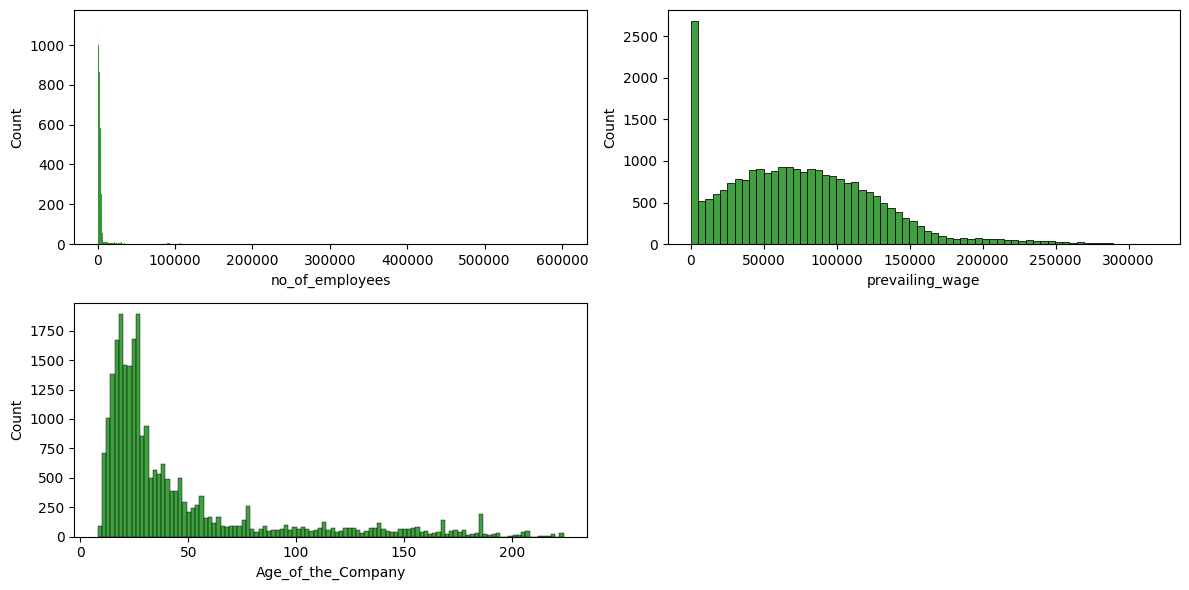

In [34]:
# distribution of data before scaling
plt.figure(figsize=(12, 6))
for i, col in enumerate(['no_of_employees','prevailing_wage','Age_of_the_Company']):
    plt.subplot(2, 2, i+1)
    sns.histplot(x=X[col], color='green')
    plt.xlabel(col)
    plt.tight_layout()

* No of employees and Age of the company column is skewed
* Need to apply a power transform featurewise to make data more Gaussian-like.

Power transforms are a family of parametric, monotonic transformations that are applied to make data more Gaussian-like. This is useful for modeling issues related to heteroscedasticity (non-constant variance), or other situations where normality is desired.

Currently, PowerTransformer supports the Box-Cox transform and the Yeo-Johnson transform.

**Checking Skewness**

**What is Skewness ?**

* Skewness refers to a distortion or asymmetry that deviates from the symmetrical bell curve, or normal distribution, in a set of data. If the curve is shifted to the left or to the right, it is said to be skewed. Skewness can be quantified as a representation of the extent to which a given distribution varies from a normal distribution. A normal distribution has a skew of zero

In [36]:
# Check Skewness
X[Continuous_features].skew(axis=0, skipna=True)

no_of_employees       12.265260
prevailing_wage        0.755776
Age_of_the_Company     2.037301
dtype: float64